from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive

In [ ]:
%cd /content/drive/MyDrive

[Errno 2] No such file or directory: '/content/drive/MyDrive'
/content/The_Overfitters


In [ ]:
!git clone https://github.com/krish-ktm/The_Overfitters.git

Cloning into 'The_Overfitters'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 3), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 97.01 KiB | 841.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
%cd The_Overfitters

/content/The_Overfitters


In [ ]:
!ls

dataset.py  PROJECT_ABSTRACT.md  README.md	   scripts
models	    Proposal		 requirements.txt  utils


In [ ]:
!git config --global user.name "Ashwini Vitekar"
!git config --global user.email "vitekarashwini26@gmail.com"


In [ ]:
!git config --global user.name
!git config --global user.email

Ashwini Vitekar
vitekarashwini26@gmail.com


In [ ]:
!cat dataset.py

import os
import glob
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset

class KaggleNucleiDataset(Dataset):
    """
    PyTorch Dataset handle for the Kaggle 2018 Data Science Bowl (Nuclei Segmentation).
    Industry standard handling of paths, resizing, and tensor conversions.
    """
    def __init__(self, root_dir, image_size=256, transform=None):
        """
        Args:
            root_dir (string): Directory with all the image ID folders (e.g. data/kaggle_2018/stage1_train)
            image_size (int): Size to resize the images to (U-Net usually likes 256 or 512).
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.image_size = image_size
        self.transform = transform
        
        # The Kaggle dataset contains one folder per image ID
        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Directory {root_dir} not found. 

In [ ]:
!find . -maxdepth 3 -type d

.
./models
./Proposal
./.git
./.git/refs
./.git/refs/remotes
./.git/refs/heads
./.git/refs/tags
./.git/logs
./.git/logs/refs
./.git/objects
./.git/objects/info
./.git/objects/pack
./.git/info
./.git/branches
./.git/hooks
./utils
./scripts


In [ ]:
!mkdir -p data/nuclei

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ashwinivitekar","key":"4863f147e188a8323021e7c474311034"}'}

In [ ]:
import os

# Create Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json there
!cp kaggle.json /root/.kaggle/

# Set correct permissions (required)
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle setup done ✅")

Kaggle setup done ✅


In [ ]:
!kaggle datasets list -s nuclei

ref                                                          title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
espsiyam/nuclei-image-segmentation                           Nuclei Segmentation                                  93792840  2021-05-07 07:06:17.917000            663         15  0.625            
gangadhar/nuclei-segmentation-in-microscope-cell-images      Nuclei Segmentation In Microscope Cell Images       389536741  2018-04-20 06:43:19.193000           4272         58  0.7058824        
andrewmvd/cancer-inst-segmentation-and-classification        Cancer Instance Segmentation and Classification 1  1412556966  2022-05-08 12:42:10.597000           3132         49  0.875            
uciml/breast-cancer-

In [ ]:
!kaggle competitions download -c data-science-bowl-2018 -p data/nuclei

100% 358M/358M [00:02<00:00, 139MB/s]



In [ ]:
import zipfile
import os

zip_path = 'data/nuclei/data-science-bowl-2018.zip'
extract_path = 'data/nuclei'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Successfully extracted {zip_path} to {extract_path}')

Successfully extracted data/nuclei/data-science-bowl-2018.zip to data/nuclei


In [ ]:
!ls data/nuclei/


data-science-bowl-2018.zip	  stage1_train_labels.csv.zip
stage1_sample_submission.csv.zip  stage1_train.zip
stage1_solution.csv.zip		  stage2_sample_submission_final.csv.zip
stage1_test.zip			  stage2_test_final.zip


In [ ]:
!unzip -qo data/nuclei/stage1_train.zip -d data/nuclei/

In [ ]:
!find data/nuclei -maxdepth 2 -type d

data/nuclei
...


In [ ]:
from dataset import KaggleNucleiDataset

dataset = KaggleNucleiDataset(root_dir="data/nuclei", image_size=256)

print("Dataset size:", len(dataset))

Dataset size: 670


In [ ]:
image, mask = dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)
print("Mask unique values:", mask.unique())

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Mask unique values: tensor([0., 1.])


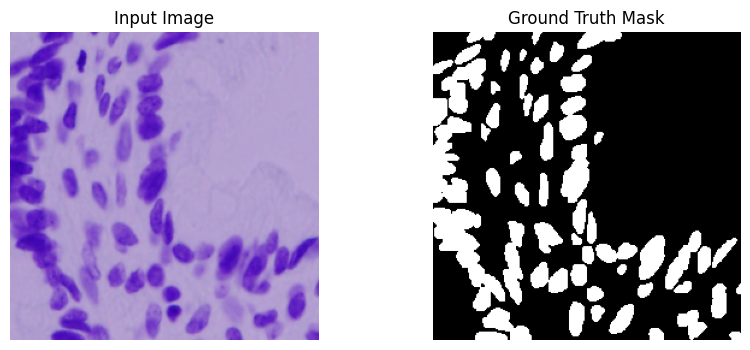

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0).numpy())
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(0).numpy(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [ ]:
from torch.utils.data import DataLoader, random_split

# Split dataset (80% train, 20% val)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 536
Val size: 134


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        u4 = self.up4(b)
        u4 = torch.cat([u4, e4], dim=1)
        d4 = self.dec4(u4)

        u3 = self.up3(d4)
        u3 = torch.cat([u3, e3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.up2(d3)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        return self.final(d1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_unet = UNet(in_channels=3, out_channels=1).to(device)

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

outputs = model_unet(images)

print("Input batch shape :", images.shape)
print("Mask batch shape  :", masks.shape)
print("Output batch shape:", outputs.shape)

Input batch shape : torch.Size([8, 3, 256, 256])
Mask batch shape  : torch.Size([8, 1, 256, 256])
Output batch shape: torch.Size([8, 1, 256, 256])


In [ ]:
class UNetNoSkip(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(512, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        u4 = self.up4(b)
        d4 = self.dec4(u4)

        u3 = self.up3(d4)
        d3 = self.dec3(u3)

        u2 = self.up2(d3)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        d1 = self.dec1(u1)

        return self.final(d1)

In [ ]:
model_no_skip = UNetNoSkip(in_channels=3, out_channels=1).to(device)

outputs_no_skip = model_no_skip(images)

print("Input batch shape :", images.shape)
print("Mask batch shape  :", masks.shape)
print("Output batch shape:", outputs_no_skip.shape)

Input batch shape : torch.Size([8, 3, 256, 256])
Mask batch shape  : torch.Size([8, 1, 256, 256])
Output batch shape: torch.Size([8, 1, 256, 256])


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer_unet = torch.optim.Adam(model_unet.parameters(), lr=1e-3)
optimizer_no_skip = torch.optim.Adam(model_no_skip.parameters(), lr=1e-3)

print("Loss and optimizers ready")

Loss and optimizers ready


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
num_epochs = 5

train_losses_unet = []
val_losses_unet = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_unet, train_loader, optimizer_unet, criterion, device)
    val_loss = validate_one_epoch(model_unet, val_loader, criterion, device)

    train_losses_unet.append(train_loss)
    val_losses_unet.append(val_loss)

    print(f"U-Net Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

U-Net Epoch [1/5] | Train Loss: 1.1098 | Val Loss: 0.3897
U-Net Epoch [2/5] | Train Loss: 0.2850 | Val Loss: 0.2051
U-Net Epoch [3/5] | Train Loss: 0.2018 | Val Loss: 0.1794
U-Net Epoch [4/5] | Train Loss: 0.1922 | Val Loss: 0.1742
U-Net Epoch [5/5] | Train Loss: 0.1837 | Val Loss: 0.1818


In [ ]:
num_epochs = 5

train_losses_noskip = []
val_losses_noskip = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_no_skip, train_loader, optimizer_no_skip, criterion, device)
    val_loss = validate_one_epoch(model_no_skip, val_loader, criterion, device)

    train_losses_noskip.append(train_loss)
    val_losses_noskip.append(val_loss)

    print(f"No-Skip Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

No-Skip Epoch [1/5] | Train Loss: 0.4314 | Val Loss: 0.3928
No-Skip Epoch [2/5] | Train Loss: 0.4096 | Val Loss: 0.3982
No-Skip Epoch [3/5] | Train Loss: 0.4111 | Val Loss: 0.3953
No-Skip Epoch [4/5] | Train Loss: 0.4100 | Val Loss: 0.3926
No-Skip Epoch [5/5] | Train Loss: 0.4080 | Val Loss: 0.3925


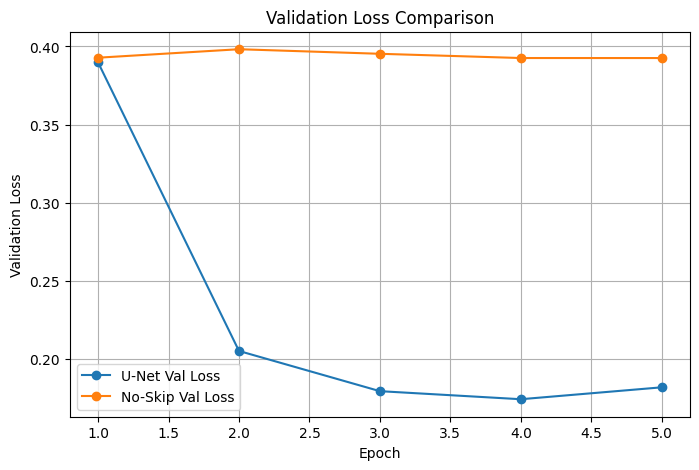

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_losses_unet, marker='o', label='U-Net Val Loss')
plt.plot(epochs, val_losses_noskip, marker='o', label='No-Skip Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

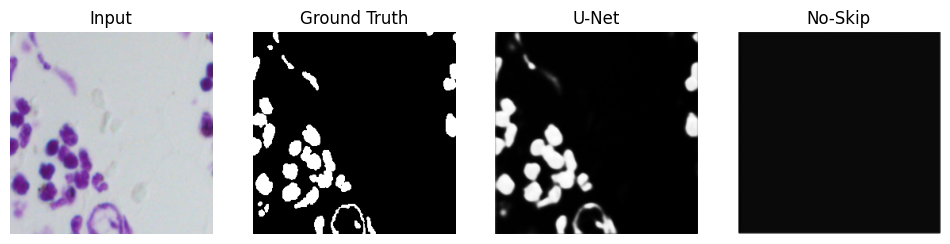

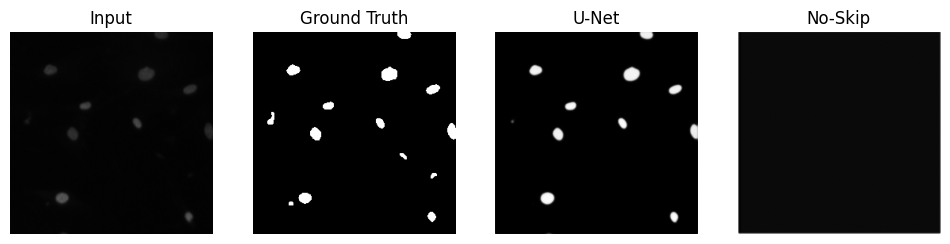

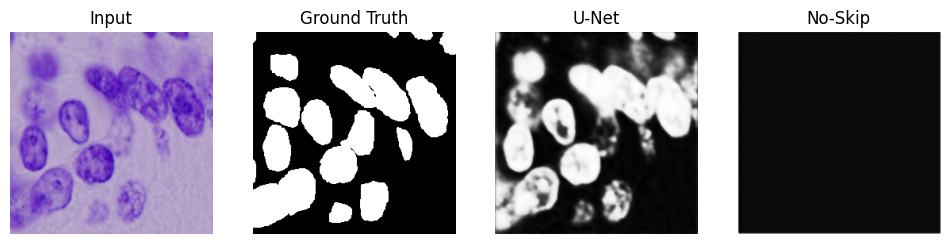

In [ ]:
model_unet.eval()
model_no_skip.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds_unet = torch.sigmoid(model_unet(images))
    preds_noskip = torch.sigmoid(model_no_skip(images))

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(12,4))

    # Input
    plt.subplot(1,4,1)
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title("Input")
    plt.axis("off")

    # Ground truth
    plt.subplot(1,4,2)
    plt.imshow(masks[i].squeeze(0), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # U-Net prediction
    plt.subplot(1,4,3)
    plt.imshow(preds_unet[i].cpu().squeeze(0), cmap='gray')
    plt.title("U-Net")
    plt.axis("off")

    # No-skip prediction
    plt.subplot(1,4,4)
    plt.imshow(preds_noskip[i].cpu().squeeze(0), cmap='gray')
    plt.title("No-Skip")
    plt.axis("off")

    plt.show()

In [ ]:
def dice_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def iou_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-8)

In [ ]:
def evaluate_metrics(model, loader, device, threshold=0.5):
    model.eval()
    total_dice = 0.0
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            total_dice += dice_score(probs, masks, threshold=threshold).item()
            total_iou += iou_score(probs, masks, threshold=threshold).item()
            num_batches += 1

    return total_dice / num_batches, total_iou / num_batches


dice_unet, iou_unet = evaluate_metrics(model_unet, val_loader, device)
dice_noskip, iou_noskip = evaluate_metrics(model_no_skip, val_loader, device)

print(f"U-Net     -> Dice: {dice_unet:.4f}, IoU: {iou_unet:.4f}")
print(f"No-Skip   -> Dice: {dice_noskip:.4f}, IoU: {iou_noskip:.4f}")

U-Net     -> Dice: 0.7133, IoU: 0.5598
No-Skip   -> Dice: 0.0000, IoU: 0.0000


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["U-Net", "No-Skip"],
    "Validation Loss": [val_losses_unet[-1], val_losses_noskip[-1]],
    "Dice Score": [dice_unet, dice_noskip],
    "IoU Score": [iou_unet, iou_noskip]
})

results_df

,Model,Validation Loss,Dice Score,IoU Score
0,U-Net,0.181843,0.713291,0.559837
1,No-Skip,0.392546,0.000000,0.000000


In [ ]:
num_extra_epochs = 5  # continue from 5 → total 10

for epoch in range(num_extra_epochs):
    train_loss = train_one_epoch(model_unet, train_loader, optimizer_unet, criterion, device)
    val_loss = validate_one_epoch(model_unet, val_loader, criterion, device)

    train_losses_unet.append(train_loss)
    val_losses_unet.append(val_loss)

    print(f"U-Net Epoch [{len(train_losses_unet)}/{len(train_losses_unet)}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

U-Net Epoch [6/6] | Train Loss: 0.4391 | Val Loss: 0.1961
U-Net Epoch [7/7] | Train Loss: 0.1911 | Val Loss: 0.1739
U-Net Epoch [8/8] | Train Loss: 0.1741 | Val Loss: 0.1680
U-Net Epoch [9/9] | Train Loss: 0.1697 | Val Loss: 0.1813
U-Net Epoch [10/10] | Train Loss: 0.1726 | Val Loss: 0.1608


In [ ]:
dice_unet, iou_unet = evaluate_metrics(model_unet, val_loader, device)
print(f"Final U-Net -> Dice: {dice_unet:.4f}, IoU: {iou_unet:.4f}")

Final U-Net -> Dice: 0.7576, IoU: 0.6146


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["U-Net", "No-Skip"],
    "Validation Loss": [val_losses_unet[-1], val_losses_noskip[-1]],
    "Dice Score": [dice_unet, dice_noskip],
    "IoU Score": [iou_unet, iou_noskip]
})

results_df

,Model,Validation Loss,Dice Score,IoU Score
0,U-Net,0.160800,0.757563,0.614639
1,No-Skip,0.392546,0.000000,0.000000
